In [1]:
# importing required modules
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.circuit import Gate, QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error
from qiskit.quantum_info import partial_trace, state_fidelity, DensityMatrix
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# define all the parameters of the simulation

# imperfect Bell pair preparation parameters
p_w_vals   = [0.0, 0.05, 0.10] # depolarizing probability of the generated Bell pairs

# quantum memory decoherence parameters
t_mem_vals = np.linspace(0, 200, 15) # memory time
t_phi_vals = [500.0, 1000.0, 2000.0] # pure dephasing time
t_1_vals   = [500.0, 1000.0, 2000.0] # relaxation time

NOMINAL_PW = 0.02
NOMINAL_DECO = 1000.0

In [3]:
# define utility gates

# Bell gate definition
class BellGate(Gate):
    def __init__(self):
        super().__init__("bell_gate", 2, [])

    def _define(self):
        qc = QuantumCircuit(2, name=self.name)
        qc.h(0)
        qc.cnot(0, 1)
        self.definition = qc

# reverse Bell gate definition
class ReverseBellGate(Gate):
    def __init__(self):
        super().__init__("reverse_bell_gate", 2, [])

    def _define(self):
        qc = QuantumCircuit(2, name=self.name)
        qc.cx(0, 1)
        qc.h(0)
        self.definition = qc

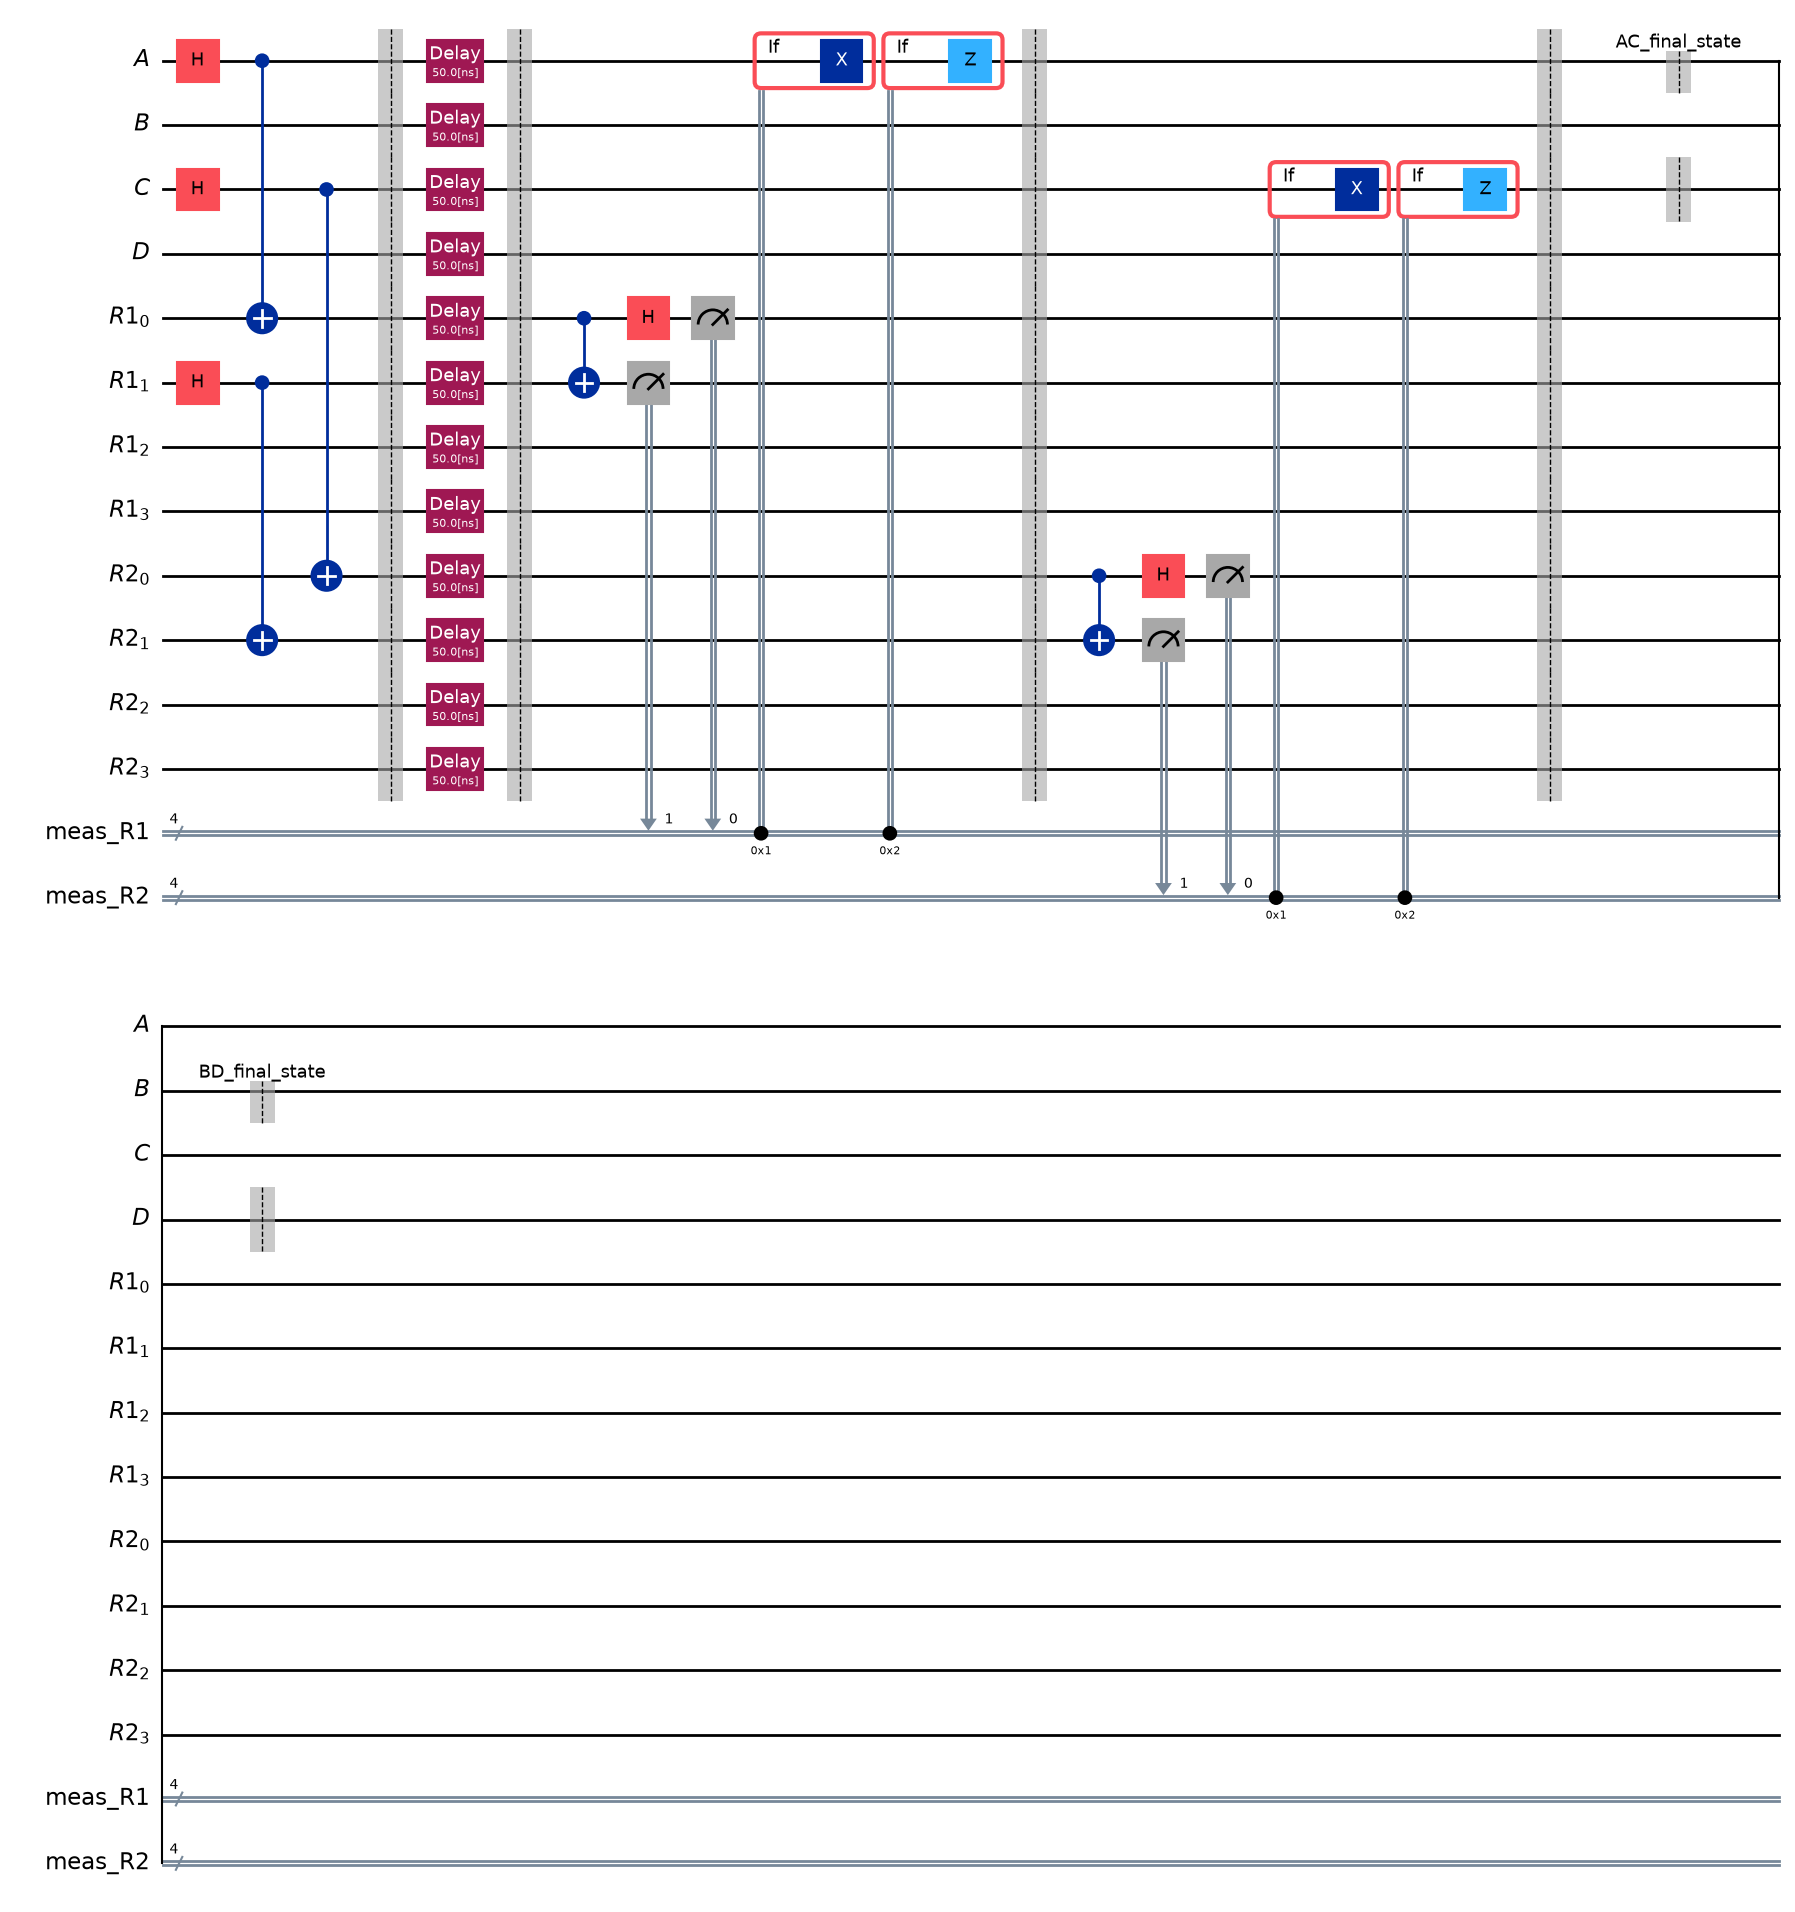

In [4]:
# define the function for creating the quantum circuit network
def create_circuit_network(t_mem):
    
    # define and initialize all the registers in the network
    qr_A = QuantumRegister(1, name="A")
    qr_B = QuantumRegister(1, name="B")
    qr_C = QuantumRegister(1, name="C")
    qr_D = QuantumRegister(1, name="D")
    qr_R1 = QuantumRegister(4, name="R1")
    qr_R2 = QuantumRegister(4, name="R2")
    
    cr_R1 = ClassicalRegister(4, name="meas_R1")
    cr_R2 = ClassicalRegister(4, name="meas_R2")
    
    qc = QuantumCircuit(qr_A, qr_B, qr_C, qr_D, qr_R1, qr_R2, cr_R1, cr_R2)    

    
    # imperfect Bell pair preparation
    bell = BellGate()

    qc.h(qr_A[0])
    qc.cx(qr_A[0], qr_R1[0])

    qc.h(qr_R1[1])
    qc.cx(qr_R1[1], qr_R2[1])

    qc.h(qr_C[0])
    qc.cx(qr_C[0], qr_R2[0])
    
    # qc.append(bell, [qr_A[0], qr_R1[0]])
    # qc.append(bell, [qr_R1[1], qr_R2[1]])
    # qc.append(bell, [qr_R2[0], qr_C[0]])
    qc.barrier()
    
    
    # delay for quantum memory decoherence    
    qc.delay(t_mem, qc.qubits, unit="ns")
    qc.barrier()
    
    
    # entanglement swapping and corrections
    reverse_bell = ReverseBellGate()
    
    # qc.append(reverse_bell, [qr_R1[0], qr_R1[1]])
    qc.cx(qr_R1[0], qr_R1[1])
    qc.h(qr_R1[0])
    qc.measure(qr_R1[0], cr_R1[0])
    qc.measure(qr_R1[1], cr_R1[1])
    
    with qc.if_test((cr_R1, 1)):
        qc.x(qr_A[0])
    with qc.if_test((cr_R1, 2)):
        qc.z(qr_A[0])
    qc.barrier()
    
    # qc.append(reverse_bell, [qr_R2[0], qr_R2[1]])
    qc.cx(qr_R2[0], qr_R2[1])
    qc.h(qr_R2[0])
    qc.measure(qr_R2[0], cr_R2[0])
    qc.measure(qr_R2[1], cr_R2[1])
    
    with qc.if_test((cr_R2, 1)):
        qc.x(qr_C[0])
    with qc.if_test((cr_R2, 2)):
        qc.z(qr_C[0])
    qc.barrier()
    
    # add final state saving
    qc.save_density_matrix([0, 2], label="AC_final_state")
    qc.save_density_matrix([1, 3], label="BD_final_state")
    
    return qc

qc = create_circuit_network(50.0)
# print(qc.draw(output='text'))
qc.draw("mpl")

In [5]:
def create_noise_model(p_w, t_mem, mode, t_deco):
    noise_model = NoiseModel()

    bell_generation_error = depolarizing_error(p_w, 2)
    # noise_model.add_all_qubit_quantum_error(bell_generation_error, ['bell_gate'])
    noise_model.add_quantum_error(bell_generation_error, ["cx"], [0, 4])
    noise_model.add_quantum_error(bell_generation_error, ["cx"], [5, 9])
    noise_model.add_quantum_error(bell_generation_error, ["cx"], [2, 8])
    
    if t_mem > 0:
        if mode == "dephasing":
            memory_error = thermal_relaxation_error(t1=float('inf'), t2=t_deco, time=t_mem)
        elif mode == "damping":
            memory_error = thermal_relaxation_error(t1=t_deco, t2=2*t_deco, time=t_mem)
            
        noise_model.add_all_qubit_quantum_error(memory_error, ['delay'])

    return noise_model

In [6]:
# simulations

data_dephasing = {}
data_damping   = {}
data_pw        = {}

bell_target = DensityMatrix(np.array([1, 0, 0, 1]) / np.sqrt(2))

for t_phi in t_phi_vals:
    fidelities = []
    for t in t_mem_vals:
        qc = create_circuit_network(t_mem=t)
        noise = create_noise_model(p_w=NOMINAL_PW, t_mem=t, mode="dephasing", t_deco=t_phi)
        sim = AerSimulator(method="density_matrix", noise_model=noise)
        
        AC_matrix = sim.run(qc).result().data()["AC_final_state"]
        fidelities.append(state_fidelity(AC_matrix, bell_target))
    data_dephasing[t_phi] = fidelities

for t_1 in t_1_vals:
    fidelities = []
    for t in t_mem_vals:
        qc = create_circuit_network(t_mem=t)
        noise = create_noise_model(p_w=NOMINAL_PW, t_mem=t, mode="damping", t_deco=t_1)
        sim = AerSimulator(method="density_matrix", noise_model=noise)
        
        AC_matrix = sim.run(qc).result().data()["AC_final_state"]
        fidelities.append(state_fidelity(AC_matrix, bell_target))
    data_damping[t_1] = fidelities

for pw in p_w_vals:
    fidelities = []
    for t in t_mem_vals:
        qc = create_circuit_network(t_mem=t)
        noise = create_noise_model(p_w=pw, t_mem=t, mode="dephasing", t_deco=NOMINAL_DECO)
        sim = AerSimulator(method="density_matrix", noise_model=noise)
        
        AC_matrix = sim.run(qc).result().data()["AC_final_state"]
        fidelities.append(state_fidelity(AC_matrix, bell_target))
    data_pw[pw] = fidelities

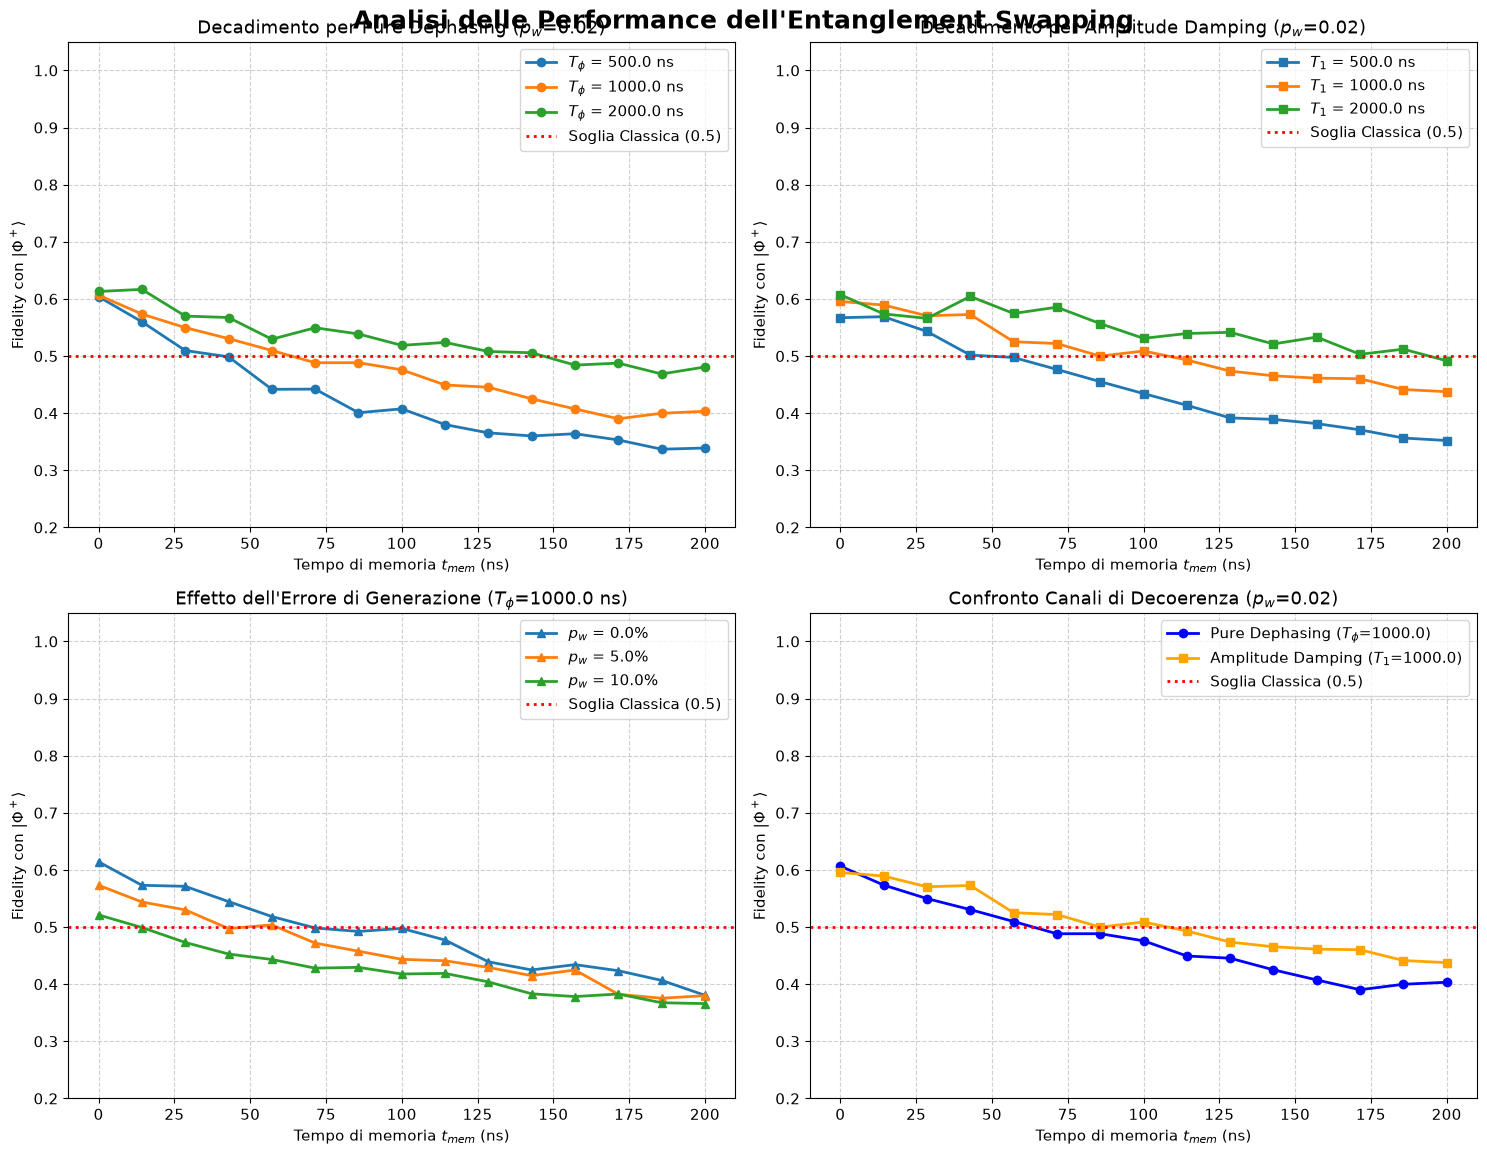

In [7]:
# Impostazioni di stile per grafici professionali
plt.rcParams.update({'font.size': 11, 'lines.linewidth': 2, 'lines.markersize': 6})

# Creiamo una griglia 2x2 per i grafici
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Analisi delle Performance dell\'Entanglement Swapping', fontsize=18, fontweight='bold', y=0.96)

# Linea di soglia classica da inserire in ogni grafico
def add_classical_threshold(ax):
    ax.axhline(y=0.5, color='red', linestyle=':', label='Soglia Classica (0.5)')

# ---------------------------------------------------------
# GRAFICO 1: Impatto del Pure Dephasing (T_phi)
# ---------------------------------------------------------
ax = axs[0, 0]
for t_phi, fid_list in data_dephasing.items():
    ax.plot(t_mem_vals, fid_list, marker='o', label=f'$T_\\phi$ = {t_phi} ns')
add_classical_threshold(ax)
ax.set_title(f'Decadimento per Pure Dephasing ($p_w$={NOMINAL_PW})')
ax.set_xlabel('Tempo di memoria $t_{mem}$ (ns)')
ax.set_ylabel('Fidelity con $|\\Phi^+\\rangle$')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
ax.set_ylim(0.2, 1.05)

# ---------------------------------------------------------
# GRAFICO 2: Impatto dell'Amplitude Damping (T_1)
# ---------------------------------------------------------
ax = axs[0, 1]
for t_1, fid_list in data_damping.items():
    ax.plot(t_mem_vals, fid_list, marker='s', label=f'$T_1$ = {t_1} ns')
add_classical_threshold(ax)
ax.set_title(f'Decadimento per Amplitude Damping ($p_w$={NOMINAL_PW})')
ax.set_xlabel('Tempo di memoria $t_{mem}$ (ns)')
ax.set_ylabel('Fidelity con $|\\Phi^+\\rangle$')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
ax.set_ylim(0.2, 1.05)

# ---------------------------------------------------------
# GRAFICO 3: Impatto del Rumore di Generazione (p_w)
# ---------------------------------------------------------
ax = axs[1, 0]
for pw, fid_list in data_pw.items():
    ax.plot(t_mem_vals, fid_list, marker='^', label=f'$p_w$ = {pw*100}%')
add_classical_threshold(ax)
ax.set_title(f'Effetto dell\'Errore di Generazione ($T_\\phi$={NOMINAL_DECO} ns)')
ax.set_xlabel('Tempo di memoria $t_{mem}$ (ns)')
ax.set_ylabel('Fidelity con $|\\Phi^+\\rangle$')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
ax.set_ylim(0.2, 1.05)

# ---------------------------------------------------------
# GRAFICO 4: Confronto Diretto (Dephasing vs Damping)
# ---------------------------------------------------------
ax = axs[1, 1]
# Prendiamo un valore specifico per fare il confronto (es. 1000 ns)
compare_val = 1000.0
ax.plot(t_mem_vals, data_dephasing[compare_val], marker='o', color='blue', 
        label=f'Pure Dephasing ($T_\\phi$={compare_val})')
ax.plot(t_mem_vals, data_damping[compare_val], marker='s', color='orange', 
        label=f'Amplitude Damping ($T_1$={compare_val})')
add_classical_threshold(ax)
ax.set_title(f'Confronto Canali di Decoerenza ($p_w$={NOMINAL_PW})')
ax.set_xlabel('Tempo di memoria $t_{mem}$ (ns)')
ax.set_ylabel('Fidelity con $|\\Phi^+\\rangle$')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
ax.set_ylim(0.2, 1.05)

# Adatta il layout per evitare sovrapposizioni e mostra i grafici
plt.tight_layout()
# plt.savefig('quantum_network_results.png', dpi=300) # Decommenta per salvare un'immagine ad alta risoluzione
plt.show()